In [1]:
import pandas as pd
import numpy as np
from biom import load_table
from sklearn.decomposition import PCA, SparsePCA, IncrementalPCA
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, SubsetRandomSampler, Subset
from torch import optim
from TRPCA import trpca, utils
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm
import gc
from scipy.stats import ttest_ind
from itertools import combinations

In [2]:
table = pd.read_csv('data/control.csv', index_col=0)
age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})
shared_index = table.index.intersection(age_metadata.loc[(age_metadata.age.notna())&(age_metadata.body_site=='oralcavity')].index)
table = table.loc[shared_index].drop(columns=['study_name','study_condition','subject_id'])
age_metadata = age_metadata.loc[shared_index]

table = (table*1000).round().astype(int)
df1 = np.log(table+1)

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_66093/932335629.py:2: DtypeWarning: Columns (21,22,25,28,29,30,32,33,35,38,51,52,53,54,55,56,57,58,63,64,65,67,68,69,74,75,76,80,90,91,92,93,96,104,105,108,109,111,112,116,117,118,119,120,121,126,128,129,134) have mixed types. Specify dtype option on import or set low_memory=False.
  age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})


In [3]:
n_dimensions = 256
# # # # # # Preprocess with PCA (Re-using the PCA application code from earlier)
X1_reduced, pca1 = utils.apply_pca(df1, n_dimensions) 
df = pd.DataFrame(X1_reduced, index=df1.index)

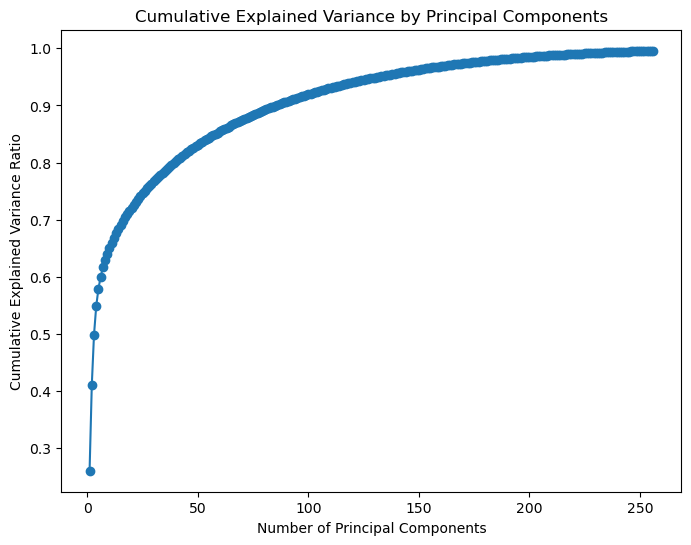

In [4]:
cum_explained_variance_ratio = np.cumsum(pca1.explained_variance_ratio_)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_explained_variance_ratio) + 1), cum_explained_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance by Principal Components')
plt.show()

In [5]:
df['age'] = age_metadata.loc[age_metadata.index.isin(df.index)].age
df = df.loc[df.age.notna()]

In [6]:
age_metadata = age_metadata.loc[df.index]

In [8]:
# Parameters
num_folds = 5
batch_size = 64
epochs = 2000

# K-Fold Cross-Validator
kf = GroupKFold(n_splits=num_folds)
# kf = KFold(n_splits=num_folds)
# Prepare full dataset (no split into train/test yet)
X = torch.tensor(df.drop(columns=['age']).to_numpy(), dtype=torch.float32)
y = torch.tensor(df.age.astype(float).to_numpy(), dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X, y)
subjects = age_metadata.subject_id
original_indices = age_metadata.index.tolist()
# Loss function, model instantiation, etc., outside the loop
criterion = nn.L1Loss()

# Dictionary to store the test indices and their corresponding predictions and true values
test_predictions = {}
fold_performance = []
# Cross-validation starts add y=y for kf split
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset, groups=subjects)):
    print(f'Fold {fold+1}/{num_folds}')
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    # DataLoaders using the subsets directly
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)  # Shuffle here if needed
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    # Reinitialize the model for each fold
    regression_model = trpca.TransformerRegressionModel(feature_size=n_dimensions, num_transformer_layers=3, nhead=8, dim_feedforward=2048, dropout=0.2, fast_transformer=True)
    optimizer = optim.SGD(regression_model.parameters(), lr=0.0003)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=0)
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
    regression_model.to(device)

    best_valid_loss = float('inf')  # Initialize the best validation loss for the fold
    best_train_loss_at_best_val = None  # Track training loss when best validation loss occurs

    # Training and validation loop
    for epoch in tqdm(range(epochs), total=len(range(epochs))):
        # Training Phase
        regression_model.train()
        train_loss = 0
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = regression_model(batch_features)
            loss = criterion(outputs['regression_output'], batch_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_features.size(0)

        train_loss /= len(train_idx)

        # Validation Phase
        regression_model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                outputs = regression_model(batch_features)
                loss = criterion(outputs['regression_output'], batch_labels)
                valid_loss += loss.item() * batch_features.size(0)

        valid_loss /= len(val_idx)

        # Epoch ends
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {valid_loss:.4f}')
        scheduler.step()
        # At the end of each epoch, evaluate on validation set
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss_at_best_val = train_loss

            # Save predictions for this fold
            all_preds = []
            all_y_true = []
            with torch.no_grad():
                for batch_features, batch_labels in val_loader:
                    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                    outputs = regression_model(batch_features)
                    all_preds.extend(outputs['regression_output'].cpu().numpy())
                    all_y_true.extend(batch_labels.cpu().numpy())

            # # Update test predictions dictionary
            # test_predictions.update({idx: (pred, true) for idx, pred, true in zip(val_idx, all_preds, all_y_true)})
            # Map the integer indices back to the original string indices
            original_val_indices = [original_indices[i] for i in val_idx]

            # Update test predictions dictionary using original indices
            test_predictions.update({orig_idx: (pred, true) for orig_idx, pred, true in zip(original_val_indices, all_preds, all_y_true)})

    # Store the best validation loss of this fold and its associated training loss
    print(f"Best loss: {best_valid_loss}")  
    fold_performance.append((best_train_loss_at_best_val, best_valid_loss))
    torch.mps.empty_cache()
    gc.collect()
# Finalize cross-validation
print("K-Fold Cross-Validation completed.")
print("Best training and validation losses for each fold:", fold_performance)

### Step 2: Plot the Predictions

# Extract the indices and predictions
indices = list(test_predictions.keys())
predictions = [test_predictions[idx][0] for idx in indices]
true_values = [test_predictions[idx][1] for idx in indices]

Fold 1/5


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 29.3823, Val Loss: 30.3014
Epoch 2/2000, Train Loss: 29.3457, Val Loss: 30.2679
Epoch 3/2000, Train Loss: 29.3076, Val Loss: 30.2371
Epoch 4/2000, Train Loss: 29.2883, Val Loss: 30.2094
Epoch 5/2000, Train Loss: 29.2579, Val Loss: 30.1864
Epoch 6/2000, Train Loss: 29.2338, Val Loss: 30.1688
Epoch 7/2000, Train Loss: 29.2235, Val Loss: 30.1565
Epoch 8/2000, Train Loss: 29.2075, Val Loss: 30.1492
Epoch 9/2000, Train Loss: 29.2035, Val Loss: 30.1458
Epoch 10/2000, Train Loss: 29.1989, Val Loss: 30.1449
Epoch 11/2000, Train Loss: 29.1866, Val Loss: 30.1094
Epoch 12/2000, Train Loss: 29.1445, Val Loss: 30.0740
Epoch 13/2000, Train Loss: 29.1119, Val Loss: 30.0382
Epoch 14/2000, Train Loss: 29.0726, Val Loss: 30.0026
Epoch 15/2000, Train Loss: 29.0376, Val Loss: 29.9683
Epoch 16/2000, Train Loss: 29.0023, Val Loss: 29.9349
Epoch 17/2000, Train Loss: 28.9704, Val Loss: 29.9032
Epoch 18/2000, Train Loss: 28.9357, Val Loss: 29.8738
Epoch 19/2000, Train Loss: 28.9087, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 29.7534, Val Loss: 29.1126
Epoch 2/2000, Train Loss: 29.7165, Val Loss: 29.0780
Epoch 3/2000, Train Loss: 29.6819, Val Loss: 29.0461
Epoch 4/2000, Train Loss: 29.6517, Val Loss: 29.0185
Epoch 5/2000, Train Loss: 29.6209, Val Loss: 28.9955
Epoch 6/2000, Train Loss: 29.6011, Val Loss: 28.9772
Epoch 7/2000, Train Loss: 29.5859, Val Loss: 28.9650
Epoch 8/2000, Train Loss: 29.5765, Val Loss: 28.9578
Epoch 9/2000, Train Loss: 29.5681, Val Loss: 28.9544
Epoch 10/2000, Train Loss: 29.5655, Val Loss: 28.9536
Epoch 11/2000, Train Loss: 29.5532, Val Loss: 28.9182
Epoch 12/2000, Train Loss: 29.5167, Val Loss: 28.8826
Epoch 13/2000, Train Loss: 29.4791, Val Loss: 28.8474
Epoch 14/2000, Train Loss: 29.4486, Val Loss: 28.8129
Epoch 15/2000, Train Loss: 29.4165, Val Loss: 28.7797
Epoch 16/2000, Train Loss: 29.3774, Val Loss: 28.7477
Epoch 17/2000, Train Loss: 29.3552, Val Loss: 28.7177
Epoch 18/2000, Train Loss: 29.3179, Val Loss: 28.6893
Epoch 19/2000, Train Loss: 29.2945, V

...

Epoch 1/2000, Train Loss: 29.8232, Val Loss: 28.9516
Epoch 2/2000, Train Loss: 29.7923, Val Loss: 28.9224
Epoch 3/2000, Train Loss: 29.7648, Val Loss: 28.8954
Epoch 4/2000, Train Loss: 29.7374, Val Loss: 28.8716
Epoch 5/2000, Train Loss: 29.7142, Val Loss: 28.8521
Epoch 6/2000, Train Loss: 29.6955, Val Loss: 28.8371
Epoch 7/2000, Train Loss: 29.6830, Val Loss: 28.8267
Epoch 8/2000, Train Loss: 29.6728, Val Loss: 28.8203
Epoch 9/2000, Train Loss: 29.6696, Val Loss: 28.8174
Epoch 10/2000, Train Loss: 29.6647, Val Loss: 28.8167
Epoch 11/2000, Train Loss: 29.6567, Val Loss: 28.7867
Epoch 12/2000, Train Loss: 29.6222, Val Loss: 28.7566
Epoch 13/2000, Train Loss: 29.5913, Val Loss: 28.7267
Epoch 14/2000, Train Loss: 29.5610, Val Loss: 28.6974
Epoch 15/2000, Train Loss: 29.5335, Val Loss: 28.6690
Epoch 16/2000, Train Loss: 29.5016, Val Loss: 28.6423
Epoch 17/2000, Train Loss: 29.4744, Val Loss: 28.6172
Epoch 18/2000, Train Loss: 29.4526, Val Loss: 28.5935
Epoch 19/2000, Train Loss: 29.4281, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 29.2061, Val Loss: 30.4282
Epoch 2/2000, Train Loss: 29.1708, Val Loss: 30.3935
Epoch 3/2000, Train Loss: 29.1364, Val Loss: 30.3608
Epoch 4/2000, Train Loss: 29.1077, Val Loss: 30.3323
Epoch 5/2000, Train Loss: 29.0784, Val Loss: 30.3084
Epoch 6/2000, Train Loss: 29.0517, Val Loss: 30.2897
Epoch 7/2000, Train Loss: 29.0444, Val Loss: 30.2766
Epoch 8/2000, Train Loss: 29.0309, Val Loss: 30.2688
Epoch 9/2000, Train Loss: 29.0233, Val Loss: 30.2652
Epoch 10/2000, Train Loss: 29.0257, Val Loss: 30.2643
Epoch 11/2000, Train Loss: 29.0070, Val Loss: 30.2262
Epoch 12/2000, Train Loss: 28.9672, Val Loss: 30.1872
Epoch 13/2000, Train Loss: 28.9327, Val Loss: 30.1482
Epoch 14/2000, Train Loss: 28.8886, Val Loss: 30.1098
Epoch 15/2000, Train Loss: 28.8491, Val Loss: 30.0714
Epoch 16/2000, Train Loss: 28.8187, Val Loss: 30.0349
Epoch 17/2000, Train Loss: 28.7774, Val Loss: 29.9993
Epoch 18/2000, Train Loss: 28.7445, Val Loss: 29.9659
Epoch 19/2000, Train Loss: 28.7132, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 29.7125, Val Loss: 28.9711
Epoch 2/2000, Train Loss: 29.6770, Val Loss: 28.9334
Epoch 3/2000, Train Loss: 29.6405, Val Loss: 28.8988
Epoch 4/2000, Train Loss: 29.6079, Val Loss: 28.8693
Epoch 5/2000, Train Loss: 29.5825, Val Loss: 28.8448
Epoch 6/2000, Train Loss: 29.5593, Val Loss: 28.8260
Epoch 7/2000, Train Loss: 29.5460, Val Loss: 28.8129
Epoch 8/2000, Train Loss: 29.5302, Val Loss: 28.8052
Epoch 9/2000, Train Loss: 29.5303, Val Loss: 28.8015
Epoch 10/2000, Train Loss: 29.5262, Val Loss: 28.8006
Epoch 11/2000, Train Loss: 29.5088, Val Loss: 28.7621
Epoch 12/2000, Train Loss: 29.4717, Val Loss: 28.7239
Epoch 13/2000, Train Loss: 29.4368, Val Loss: 28.6856
Epoch 14/2000, Train Loss: 29.4032, Val Loss: 28.6476
Epoch 15/2000, Train Loss: 29.3654, Val Loss: 28.6108
Epoch 16/2000, Train Loss: 29.3365, Val Loss: 28.5752
Epoch 17/2000, Train Loss: 29.3007, Val Loss: 28.5416
Epoch 18/2000, Train Loss: 29.2655, Val Loss: 28.5105
Epoch 19/2000, Train Loss: 29.2376, V

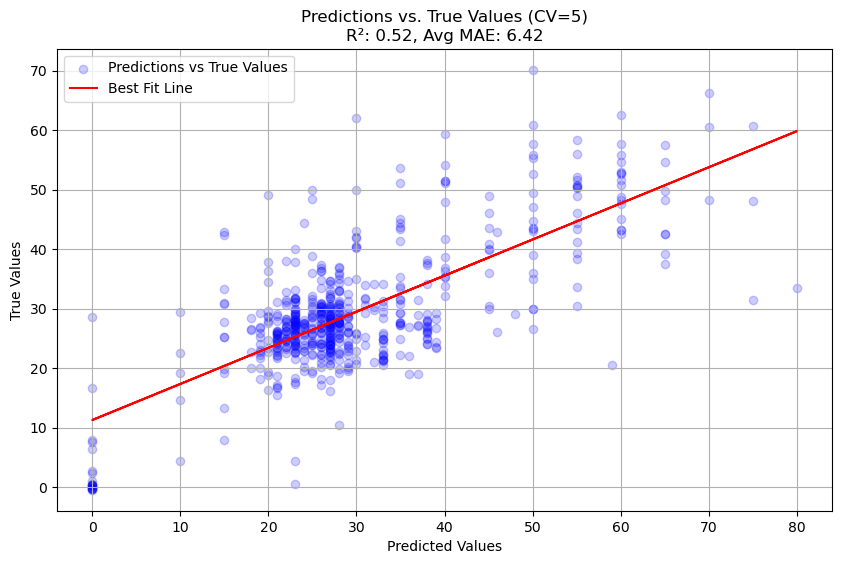

In [9]:
predictions = np.array(predictions)
true_values = np.array(true_values)

# Calculate R² and MAE
r2 = r2_score(true_values, predictions)
mae = mean_absolute_error(true_values, predictions)

# Calculate coefficients for the best fit line
slope, intercept = np.polyfit(true_values.reshape(-1), predictions.reshape(-1), 1)
best_fit_line = slope * true_values + intercept

plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, color='blue', alpha=0.2, label='Predictions vs True Values')
plt.plot(true_values, best_fit_line, color='red', label='Best Fit Line')  # Plotting the best fit line
plt.title(f'Predictions vs. True Values (CV=5)\nR²: {r2:.2f}, Avg MAE: {mae:.2f}')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.legend()
plt.grid(True)  # Optional: Adds grid for better visualization
plt.show()

### Residual analysis for metadata categories. (sex, body site, diet, disease, country of birth, acne, antibiotics, etc. )

In [10]:
# Extract predictions, true values, and original indices
predictions = [pred for _, (pred, _) in test_predictions.items()]
true_values = [true for _, (_, true) in test_predictions.items()]
indices = list(test_predictions.keys())

# Step 1: Calculate the absolute error
absolute_errors = [(pred - true)[0] for pred, true in zip(predictions, true_values)]

# Step 2: Create a DataFrame with the errors and ensure it has a common index column
error_df = pd.DataFrame({'original_index': indices, 'absolute_error': absolute_errors})

# Ensure 'original_index' in error_df is of type string for merging
error_df['original_index'] = error_df['original_index'].astype(str)

# Step 3: Ensure age_metadata has an index column that matches the original indices
age_metadata['original_index'] = age_metadata.index.astype(str)

# Merge the DataFrames using the common column 'original_index'
merged_df = pd.merge(age_metadata, error_df, on='original_index', how='inner')

In [11]:
# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'
    
def plot_residual_violin(metadata_column, merged_df):
    plt.figure(figsize=(10, 10))
    ax = sns.violinplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", hue=metadata_column, legend=False)
    sns.stripplot(x=metadata_column, y='absolute_error', data=merged_df, color='k', alpha=0.05, jitter=True)
    plt.title(f'Violin Plot of Prediction Errors by {metadata_column}')
    plt.xlabel(metadata_column)
    plt.ylabel('Absolute Error')

    # Perform a statistical test between all groups
    group_combinations = list(combinations(merged_df[metadata_column].unique(), 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = merged_df['absolute_error'].max()
    y_min = merged_df['absolute_error'].min()
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis
    categories = merged_df[metadata_column].unique()
    category_positions = {category: i for i, category in enumerate(categories)}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.show()

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind
import numpy as np

# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def plot_residual_distribution(metadata_column, merged_df):
    plt.figure(figsize=(10, 10))

    # Plot distributions
    categories = merged_df[metadata_column].unique()
    colors = sns.color_palette("muted", len(categories))
    
    for category, color in zip(categories, colors):
        subset = merged_df[merged_df[metadata_column] == category]
        sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
    
    plt.title(f'Distribution of Prediction Errors by {metadata_column}')
    plt.xlabel('Absolute Error')
    plt.ylabel('Density')

    # Perform a statistical test between all groups
    group_combinations = list(combinations(categories, 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = 0.06  # Density plots typically max out at 1
    y_min = 0
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis for annotations
    category_positions = {category: np.mean(merged_df[merged_df[metadata_column] == category]['absolute_error']) for category in categories}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.legend(title=metadata_column)
    plt.show()

# Example usage:
# plot_residual_distribution('your_metadata_column', your_merged_df)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind
import numpy as np

# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def plot_residual_boxplot(metadata_column, merged_df):
    plt.figure(figsize=(8, 8))

    # Plot boxplot
    ax = sns.boxplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", showfliers=False)
    sns.stripplot(x=metadata_column, y='absolute_error', data=merged_df, color='k', alpha=0.5, jitter=True)

    plt.title(f'Boxplot of Prediction Errors by {metadata_column}')
    plt.xlabel(metadata_column)
    plt.ylabel('Absolute Error')

    # Perform a statistical test between all groups
    categories = merged_df[metadata_column].unique()
    group_combinations = list(combinations(categories, 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = merged_df['absolute_error'].max()
    y_min = merged_df['absolute_error'].min()
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis
    category_positions = {category: i for i, category in enumerate(categories)}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.show()

# Example usage:
# plot_residual_boxplot('your_metadata_column', your_merged_df)


In [14]:
age_metadata

,study_name,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,infant_age,age_category,gender,...,hla_dqa11,hla_drb11,zigosity,brinkman_index,alcohol_numeric,breastfeeding_duration,formula_first_day,ALT,eGFR,original_index
M1.1.SA,BritoIL_2016,M1.1,oralcavity,NaN,control,healthy,40.0,NaN,adult,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M1.1.SA
M1.10.SA,BritoIL_2016,M1.10,oralcavity,NaN,control,healthy,25.0,NaN,adult,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M1.10.SA
M1.15.SA,BritoIL_2016,M1.15,oralcavity,NaN,control,healthy,50.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M1.15.SA
M1.16.SA,BritoIL_2016,M1.16,oralcavity,NaN,control,healthy,50.0,NaN,adult,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M1.16.SA
M1.20.SA,BritoIL_2016,M1.20,oralcavity,NaN,control,healthy,45.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M1.20.SA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMEA4031760,LassalleF_2017,B29,oralcavity,NaN,control,healthy,30.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMEA4031760
SAMEA4031755,LassalleF_2017,Ae61,oralcavity,NaN,control,healthy,26.0,NaN,adult,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMEA4031755
SAMEA4031754,LassalleF_2017,Ae12,oralcavity,NaN,control,healthy,30.0,NaN,adult,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMEA4031754
SAMEA4031753,LassalleF_2017,Ae10,oralcavity,NaN,control,healthy,23.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAMEA4031753


In [15]:
# Function to check if a column has significant results
def check_significance(metadata_column, merged_df):
    merged_df = merged_df.dropna(subset=[metadata_column])
    if len(merged_df[metadata_column].unique())<10:
        # Perform a statistical test between all groups
        group_combinations = list(combinations(merged_df[metadata_column].unique(), 2))
        for comb in group_combinations:
            group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
            group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
            t_stat, p_val = ttest_ind(group1, group2)
            if p_val < 0.05:
                return True
        return False
    else:
        return False
    
# Iterate through each column in age_metadata and run the analysis
significant_columns = []

for column in tqdm(age_metadata.columns, total=len(age_metadata.columns)):
    if check_significance(column, merged_df):
        significant_columns.append(column)

# Output the list of significant columns
print("Number of Significant columns:", len(significant_columns))

  0%|          | 0/141 [00:00<?, ?it/s]

Number of Significant columns: 8


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_66093/2584679727.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_stat, p_val = ttest_ind(group1, group2)
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_66093/2584679727.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may b

In [16]:
merged_df.to_csv('data/wgs_oral_residuals.tsv', sep='\t', index=True)

In [17]:
significant_columns

['study_name',
 'infant_age',
 'age_category',
 'country',
 'PMID',
 'curator',
 'days_from_first_collection',
 'location']

Comparison FJI vs USA: p-value = 0.17675671175050522
Comparison FJI vs PHL: p-value = 0.027142881490244734
Comparison USA vs PHL: p-value = 4.083597912167237e-05


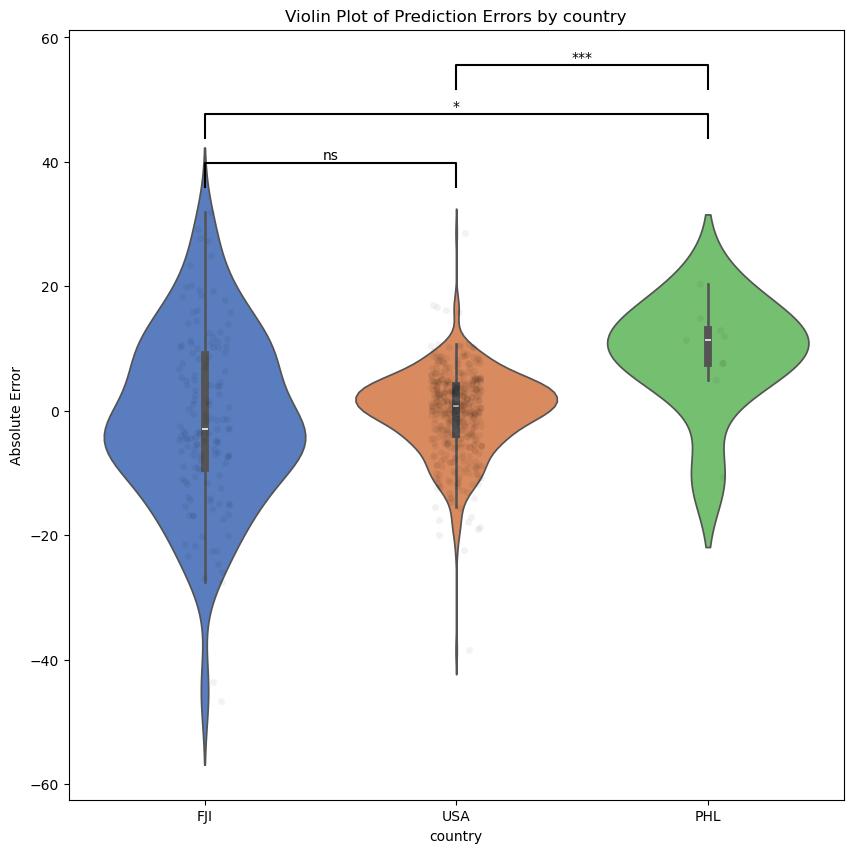

In [18]:
plot_residual_violin('country', merged_df.loc[merged_df.country.notna()])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


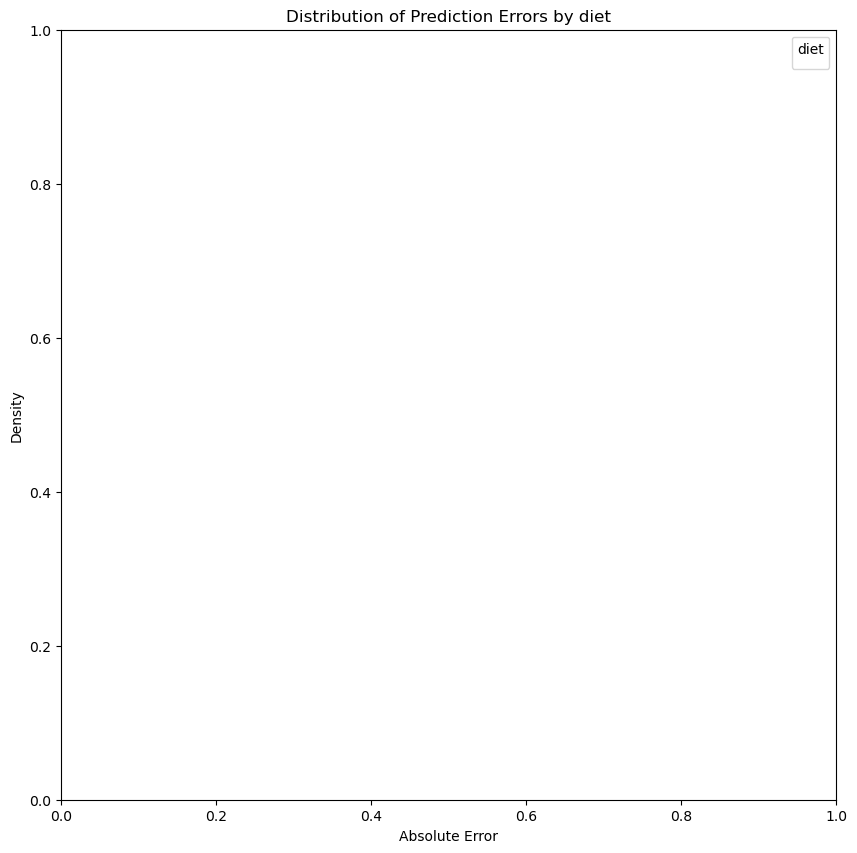

In [19]:
plot_residual_distribution('diet', merged_df.loc[merged_df.diet.notna()])

Comparison FJI vs USA: p-value = 0.17675671175050522
Comparison FJI vs PHL: p-value = 0.027142881490244734
Comparison USA vs PHL: p-value = 4.083597912167237e-05


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_66093/680936819.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", showfliers=False)


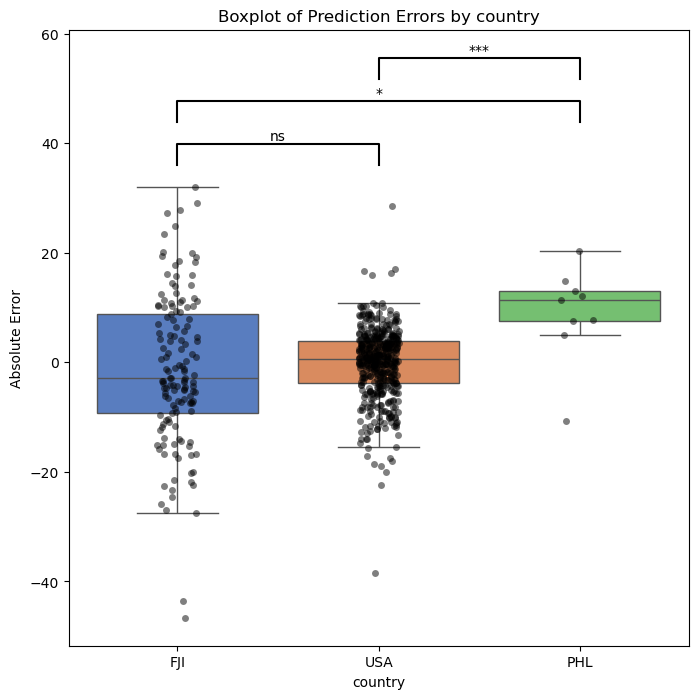

In [20]:
plot_residual_boxplot('country', merged_df.loc[merged_df.country.notna()])